# **YOLO-Objekterkennung**

Dieses Notebook führt eine **Objekterkennung mit YOLO** (Ultralytics) auf den Frames durch,
die zuvor im Notebook [`pre_processing.ipynb`](../pre_processing.ipynb) extrahiert wurden.

**Datengrundlage:** Die in `dataset/frames/<videoname>/original/` gespeicherten Einzelbilder
(1 Bild pro Sekunde) der frontal am Fahrradlenker montierten DJI-Kamera.

**Ziel:** Für den *Bikeability-Score* relevante Objekte im Straßenraum erkennen und zählen,
z. B. Fahrzeuge (Autos, LKW, Busse), andere Radfahrer, Fußgänger, Ampeln und Verkehrsschilder.
Eine hohe Dichte an motorisiertem Verkehr deutet z. B. auf eine geringere Fahrradfreundlichkeit hin.

**Ablauf des Notebooks:**

1. **Setup & Modell laden** – Ultralytics-YOLO-Modell (vortrainiert auf COCO) laden.
2. **Frames sammeln** – Alle `original`-Frames der Videos einlesen.
3. **Einzelbild-Test** – Detektion an einem Beispielframe visualisieren.
4. **Batch-Detektion** – Alle Frames verarbeiten, annotierte Bilder speichern.
5. **Auswertung** – Objektzählungen je Video für die Bikeability-Analyse aggregieren.


## 1. Setup & Imports

`pip install ultralytics opencv-python numpy matplotlib`

Beim ersten Aufruf lädt Ultralytics das Modellgewicht (`yolo11n.pt`) automatisch herunter.


In [3]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

## 2. Konfiguration

Das Notebook liegt im Ordner `research/`, die Daten daher relativ unter `../dataset/`.
Wir verarbeiten die `original`-Frames und schreiben annotierte Bilder nach
`dataset/frames/<videoname>/yolo/`.

Für die Bikeability-Analyse interessieren uns nur bestimmte COCO-Klassen
(Verkehrsteilnehmer und Verkehrsinfrastruktur).


In [29]:
# Pfade (Notebook liegt in research/, daher eine Ebene höher)
FRAMES_DIR = Path("../dataset/frames")
SOURCE_SUBDIR = "original"   # Eingangs-Frames
OUTPUT_SUBDIR = "yolo"       # Ziel für annotierte Bilder

# Modell & Inferenz-Parameter
MODEL_NAME = "yolo26n.pt"    # n = nano (schnell). Alternativen: yolo26s/m/l/x.pt
CONF_THRESHOLD = 0.45        # Mindest-Konfidenz für eine Detektion
IMG_SIZE = 960               # Inferenz-Auflösung
JPEG_QUALITY = 95
OVERWRITE = False

# Für die Bikeability relevante COCO-Klassen (Name → Kategorie)
RELEVANT_CLASSES = {
    "person": "Fußgänger",
    "bicycle": "Radfahrer",
    "car": "Kfz",
    "motorcycle": "Kfz",
    "bus": "Kfz",
    "truck": "Kfz",
    "traffic light": "Infrastruktur",
}

# Alle Videos mit vorhandenem original-Ordner finden
video_dirs = sorted(
    p.parent for p in FRAMES_DIR.glob(f"*/{SOURCE_SUBDIR}") if p.is_dir()
)

print(f"Gefundene Videos in '{FRAMES_DIR}/': {len(video_dirs)}")
for d in video_dirs:
    n = len(list((d / SOURCE_SUBDIR).glob("*.jpg")))
    print(f"  - {d.name}: {n} Frames")

if not video_dirs:
    print("\nKeine Frames gefunden. Bitte zuerst 'pre_processing.ipynb' ausführen.")


Gefundene Videos in '..\dataset\frames/': 2
  - beispiel_dji_0390: 4 Frames
  - DJI_0376: 409 Frames


## 3. Modell laden

Wir laden ein auf dem COCO-Datensatz vortrainiertes YOLO11-Modell. Es erkennt 80 Objektklassen,
darunter alle für die Bikeability relevanten Verkehrsteilnehmer.


In [25]:
model = YOLO(MODEL_NAME)

# Klassennamen → IDs (für gezieltes Filtern bei der Inferenz)
name_to_id = {name: idx for idx, name in model.names.items()}
relevant_class_ids = [name_to_id[n] for n in RELEVANT_CLASSES if n in name_to_id]

missing = [n for n in RELEVANT_CLASSES if n not in name_to_id]
if missing:
    print(f"Hinweis: nicht im Modell enthaltene Klassen werden ignoriert: {missing}")

print(f"Modell geladen: {MODEL_NAME}")
print(f"Anzahl Klassen im Modell: {len(model.names)}")
print(f"Gefilterte relevante Klassen-IDs: {relevant_class_ids}")


Modell geladen: yolo26n.pt
Anzahl Klassen im Modell: 80
Gefilterte relevante Klassen-IDs: [0, 1, 2, 3, 5, 7, 9]


## 4. Einzelbild-Test

Wir testen die Detektion an einem Beispielframe und visualisieren die erkannten Objekte
inkl. Bounding-Boxen und Konfidenzwerten.


Beispielframe: ..\dataset\frames\beispiel_dji_0390\original\frame_00227.jpg
Erkannte Objekte: {'person': 1}


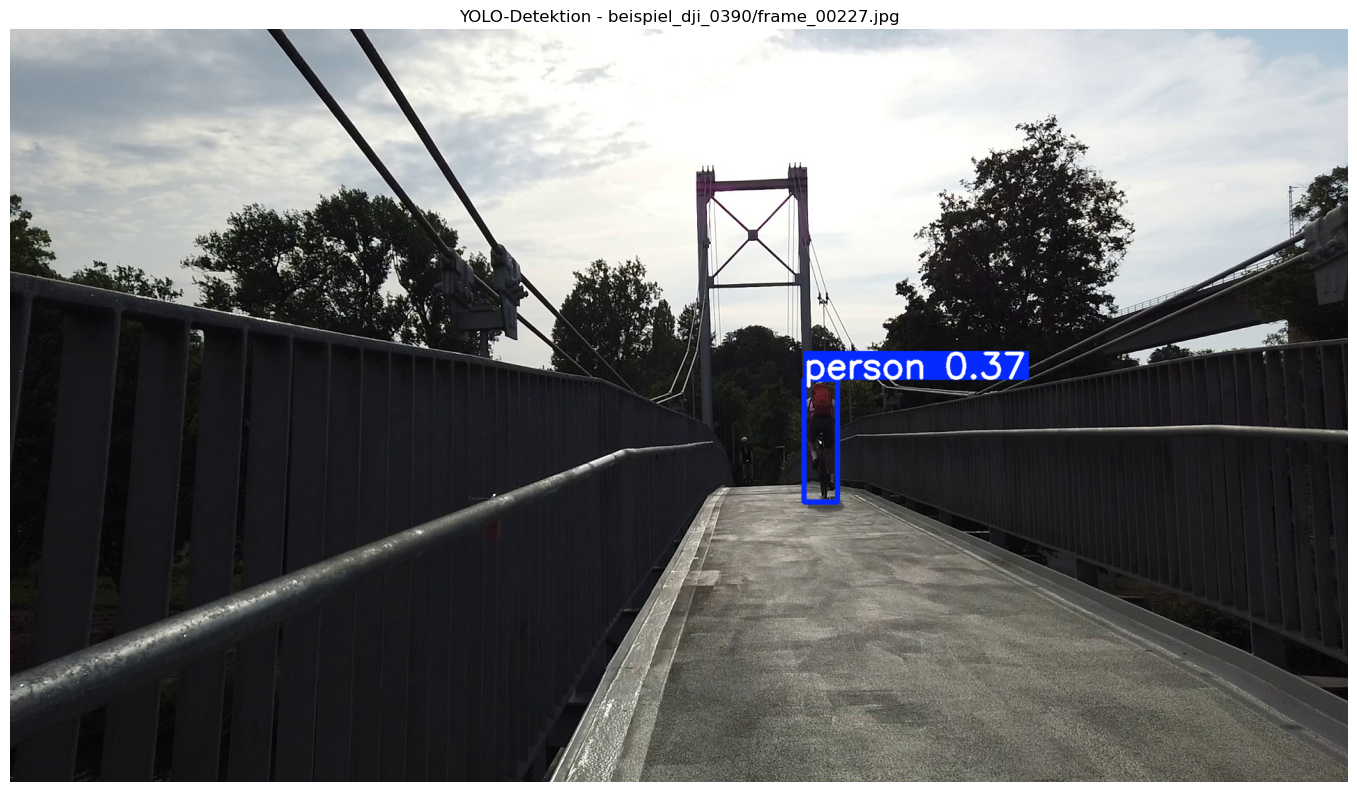

In [26]:
# Erstes verfügbares Frame als Beispiel wählen
sample_frame = None
for d in video_dirs:
    frames = sorted((d / SOURCE_SUBDIR).glob("*.jpg"))
    if frames:
        sample_frame = frames[len(frames) // 2]  # mittleres Frame
        break

if sample_frame is None:
    print("Kein Beispielframe gefunden.")
else:
    print(f"Beispielframe: {sample_frame}")

    result = model.predict(
        source=str(sample_frame),
        conf=CONF_THRESHOLD,
        imgsz=IMG_SIZE,
        classes=relevant_class_ids,
        verbose=False,
    )[0]

    # Annotiertes Bild (BGR → RGB für matplotlib)
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

    # Erkannte Objekte auflisten
    detected = Counter(model.names[int(c)] for c in result.boxes.cls)
    print("Erkannte Objekte:", dict(detected) if detected else "keine")

    plt.figure(figsize=(14, 8))
    plt.imshow(annotated)
    plt.title(f"YOLO-Detektion - {sample_frame.parent.parent.name}/{sample_frame.name}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


## 5. Batch-Detektion über alle Frames

Die folgende Funktion verarbeitet alle `original`-Frames eines Videos, speichert die annotierten
Bilder nach `dataset/frames/<videoname>/yolo/` und liefert pro Frame die gezählten Objekte zurück.


In [30]:
def detect_video_frames(
    video_dir: Path,
    overwrite: bool = False,
) -> list[dict]:
    """Detektiert relevante Objekte in allen original-Frames eines Videos.

    Annotierte Bilder werden nach <video_dir>/yolo/ geschrieben.
    Rückgabe: Liste von Dicts mit Frame-Name und Objektzählungen.
    """
    src_dir = video_dir / SOURCE_SUBDIR
    out_dir = video_dir / OUTPUT_SUBDIR
    out_dir.mkdir(parents=True, exist_ok=True)

    frame_paths = sorted(src_dir.glob("*.jpg"))
    records: list[dict] = []

    print(f"▶ {video_dir.name}: {len(frame_paths)} Frames")

    for frame_path in frame_paths:
        out_path = out_dir / frame_path.name

        result = model.predict(
            source=str(frame_path),
            conf=CONF_THRESHOLD,
            imgsz=IMG_SIZE,
            classes=relevant_class_ids,
            verbose=False,
        )[0]

        if overwrite or not out_path.exists():
            cv2.imwrite(str(out_path), result.plot(),
                        [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

        counts = Counter(model.names[int(c)] for c in result.boxes.cls)
        record = {"video": video_dir.name, "frame": frame_path.name}
        record.update({cls: counts.get(cls, 0) for cls in RELEVANT_CLASSES})
        records.append(record)

    print(f"  ✅ annotierte Bilder gespeichert in '{out_dir}'")
    return records


all_records: list[dict] = []
for video_dir in video_dirs:
    all_records.extend(detect_video_frames(video_dir, overwrite=OVERWRITE))

print(f"\nFertig. Insgesamt {len(all_records)} Frames verarbeitet.")


▶ beispiel_dji_0390: 4 Frames
  ✅ annotierte Bilder gespeichert in '..\dataset\frames\beispiel_dji_0390\yolo'
▶ DJI_0376: 409 Frames
  ✅ annotierte Bilder gespeichert in '..\dataset\frames\DJI_0376\yolo'

Fertig. Insgesamt 413 Frames verarbeitet.


## 6. Auswertung für die Bikeability-Analyse

Wir aggregieren die Detektionen je Video: Gesamtzahl pro Objektklasse sowie der
**durchschnittliche Kfz-Anteil pro Frame** als grober Indikator für die Verkehrsbelastung.
Eine höhere Kfz-Dichte deutet tendenziell auf eine geringere Fahrradfreundlichkeit hin.


In [32]:
KFZ_CLASSES = [c for c, kat in RELEVANT_CLASSES.items() if kat == "Kfz"]

# Aggregation je Video
summary: dict[str, dict] = {}
for rec in all_records:
    v = rec["video"]
    agg = summary.setdefault(v, {"frames": 0, **{c: 0 for c in RELEVANT_CLASSES}})
    agg["frames"] += 1
    for cls in RELEVANT_CLASSES:
        agg[cls] += rec[cls]

# Ausgabe als Tabelle
print(f"{'Video':<24}{'Frames':>7}", end="")
for cls in RELEVANT_CLASSES:
    print(f"{cls:>14}", end="")
print(f"{'Kfz/Frame':>12}")

for v, agg in summary.items():
    print(f"{v:<24}{agg['frames']:>7}", end="")
    for cls in RELEVANT_CLASSES:
        print(f"{agg[cls]:>14}", end="")
    kfz_total = sum(agg[c] for c in KFZ_CLASSES)
    kfz_per_frame = kfz_total / agg["frames"] if agg["frames"] else 0
    print(f"{kfz_per_frame:>12.2f}")


Video                    Frames        person       bicycle           car    motorcycle           bus         truck traffic light   Kfz/Frame
beispiel_dji_0390             4             2             0             4             0             1             1             2        1.50
DJI_0376                    409           610            95           248             8            17            41            49        0.77


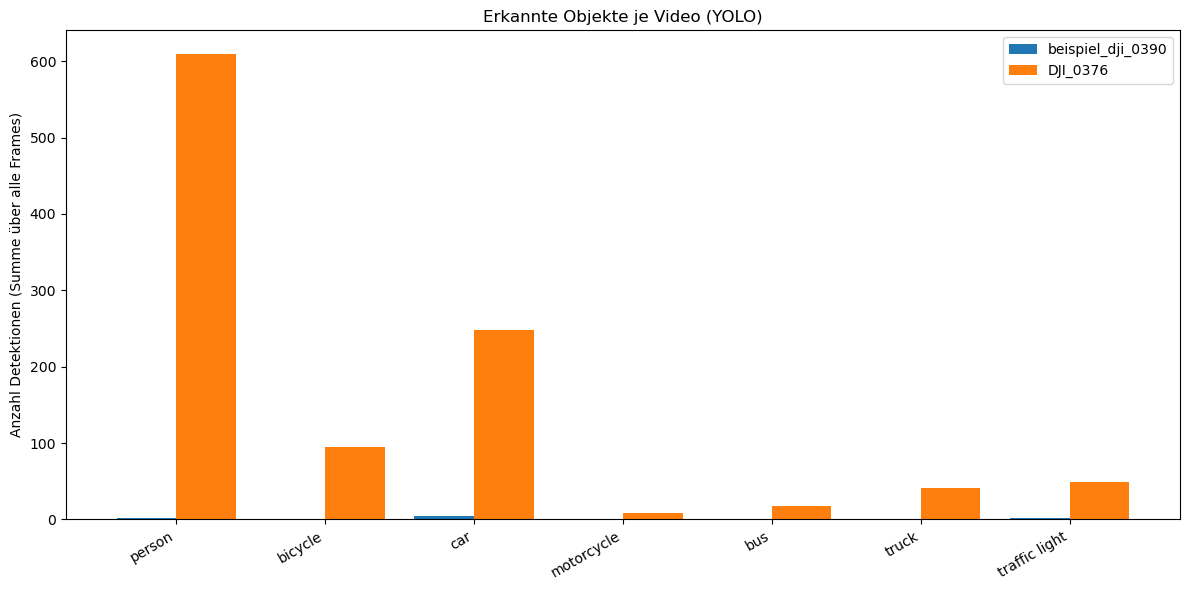

In [33]:
# Balkendiagramm der Objektzählungen je Video
if summary:
    videos = list(summary)
    classes = list(RELEVANT_CLASSES)
    x = np.arange(len(classes))
    width = 0.8 / max(1, len(videos))

    plt.figure(figsize=(12, 6))
    for i, v in enumerate(videos):
        values = [summary[v][c] for c in classes]
        plt.bar(x + i * width, values, width, label=v)

    plt.xticks(x + width * (len(videos) - 1) / 2, classes, rotation=30, ha="right")
    plt.ylabel("Anzahl Detektionen (Summe über alle Frames)")
    plt.title("Erkannte Objekte je Video (YOLO)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Keine Auswertungsdaten vorhanden.")
